In [1]:
#Výpis či je torch nainštalovaný aj pre grafiku a nie iba pre cpu

import torch
from fsspec.config import conf

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "GPU not found")

2.11.0+cu128
True
1
NVIDIA GeForce RTX 5080


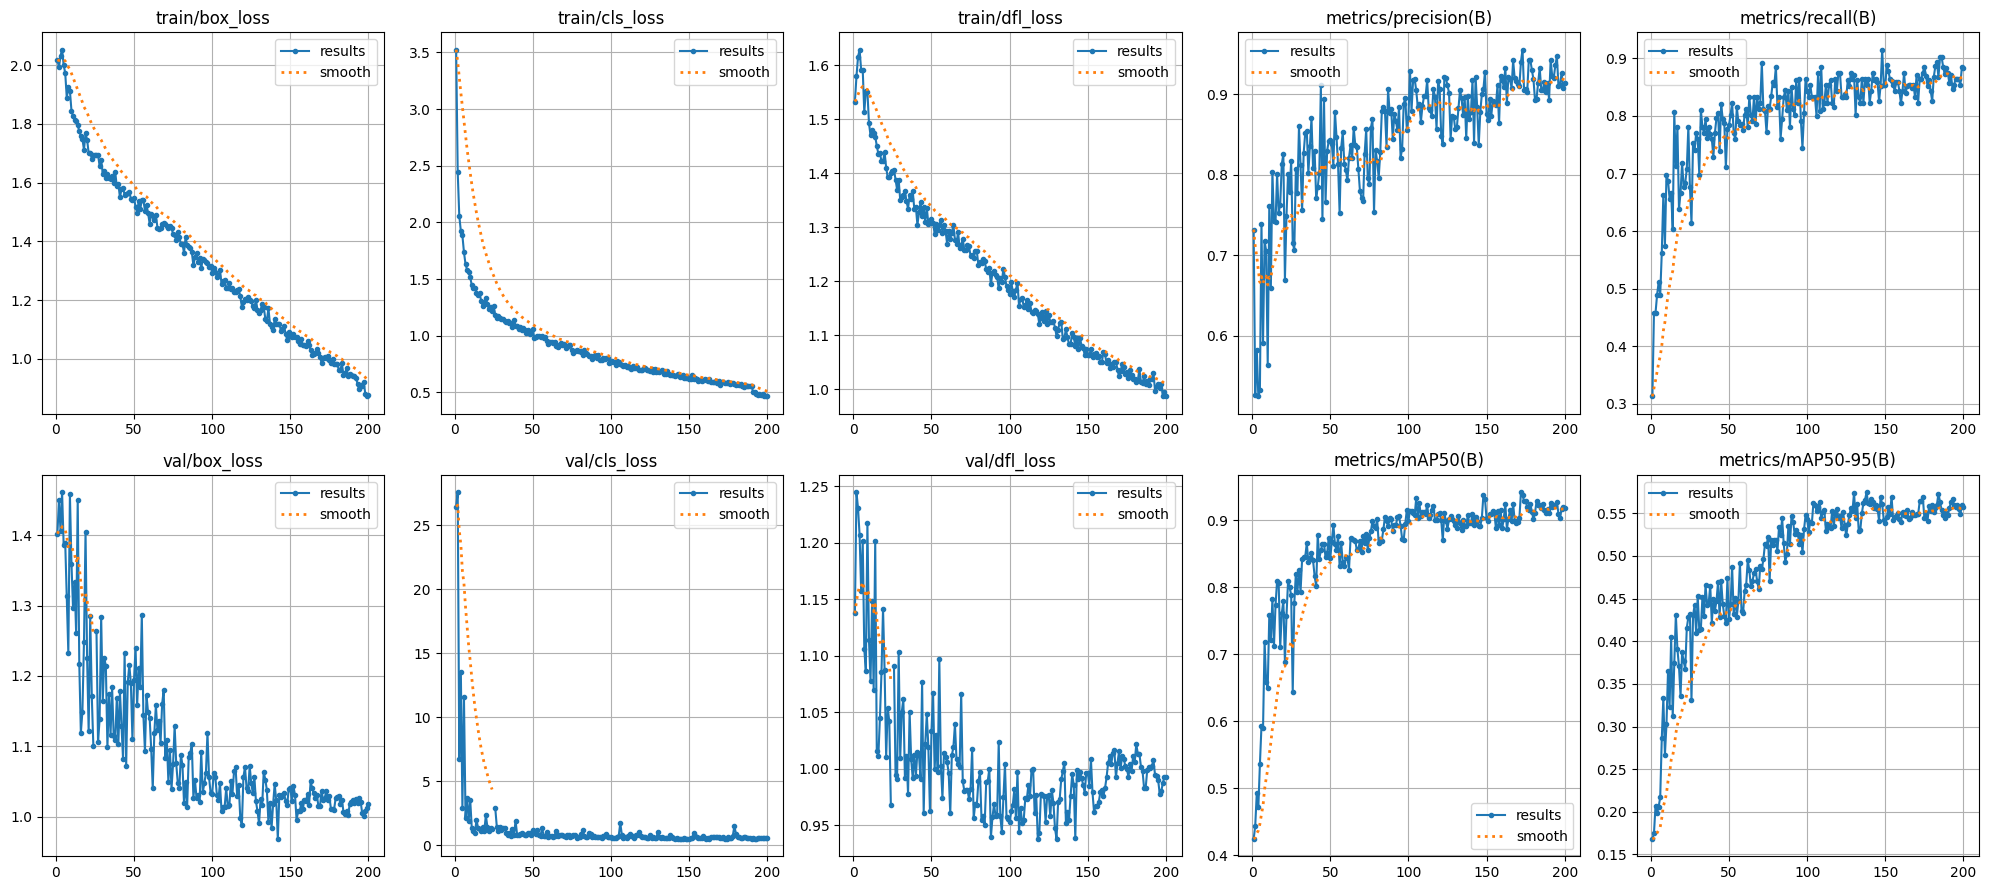

Results graf uložený ako: C:\Users\benko\Desktop\YOLO\runs\detect\validationTP\results_white.png


In [2]:
# VYTVORENIE RESULTS_WHITE.PNG Z RESULTS.CSV

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

run_dir = Path(r"C:\Users\benko\Desktop\YOLO\runs\detect\detectTP\yolo_tp_plastic_v1_n")
csv_path = run_dir / "results.csv"

output_dir = Path(r"C:\Users\benko\Desktop\YOLO\runs\detect\validationTP")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "results_white.png"

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

# x os
x = df["epoch"] if "epoch" in df.columns else range(len(df))

def smooth(y, weight=0.9):
    y = list(y)
    smoothed = []
    last = y[0]
    for point in y:
        last = last * weight + (1 - weight) * point
        smoothed.append(last)
    return smoothed

metrics_to_plot = [
    "train/box_loss",
    "train/cls_loss",
    "train/dfl_loss",
    "metrics/precision(B)",
    "metrics/recall(B)",
    "val/box_loss",
    "val/cls_loss",
    "val/dfl_loss",
    "metrics/mAP50(B)",
    "metrics/mAP50-95(B)",
]

available = [col for col in metrics_to_plot if col in df.columns]

plt.style.use("default")

fig, axes = plt.subplots(2, 5, figsize=(20, 9))
fig.patch.set_facecolor("white")

for ax, col in zip(axes.flatten(), available):
    y = df[col]

    ax.set_facecolor("white")
    ax.plot(x, y, marker=".", linewidth=1.5, label="results")
    ax.plot(x, smooth(y), linestyle=":", linewidth=2, label="smooth")

    ax.set_title(col)
    ax.grid(True)
    ax.legend()

for ax in axes.flatten()[len(available):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(output_path, facecolor="white", bbox_inches="tight", dpi=200)
plt.show()

print(f"Results graf uložený ako: {output_path}")

In [1]:
#Trénovanie

from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data="TP26_plastic_v1-1/data.yaml",
    epochs=200,
    imgsz=512,
    batch=16,
    device=0,
    project="detectTP",
    name="yolo_tp_plastic_v1_n",
    workers=0,
    pretrained=True
)

New https://pypi.org/project/ultralytics/8.4.55 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.31  Python-3.14.0 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5080, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=TP26_plastic_v1-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_

In [4]:
#Validácia

import matplotlib.pyplot as plt
import matplotlib as mpl
from ultralytics import YOLO

model = YOLO("runs/detect/detectTP/yolo_tp_plastic_v1_n/weights/best.pt")

plt.style.use("default")
mpl.rcParams["figure.facecolor"] = "white"
mpl.rcParams["axes.facecolor"] = "white"
mpl.rcParams["savefig.facecolor"] = "white"
mpl.rcParams["savefig.edgecolor"] = "white"

metrics = model.val(
    data="TP26_plastic_v1-1/data.yaml",
    project="validationTP",
    name="val_TP_plastic_v1_n",
)

print("mAP50-95:", metrics.box.map)
print("mAP50:", metrics.box.map50)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.31  Python-3.14.0 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5080, 16303MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 173.928.9 MB/s, size: 20.1 KB)
val: Scanning C:\Users\benko\Desktop\YOLO\TP26_plastic_v1-1\valid\labels.cache... 123 images, 51 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 123/123 64.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.7it/s 2.2s<0.1s
                   all        123         96      0.899      0.854      0.907      0.575
Speed: 0.6ms preprocess, 2.3ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to C:\Users\benko\Desktop\YOLO\runs\detect\validationTP\val_TP_plastic_v1_n
mAP50-95: 0.5750857729590644
mAP50: 0.90679446518309
Precision: 0.8987380392062666
Recall: 0.8541666666666666


In [1]:
#testovanie

from ultralytics import YOLO

model = YOLO("runs/detect/detectTP/yolo_tp_plastic_v1_n/weights/best.pt")

results = model.predict(
    source="TP26_plastic_v1-1/test/images",
    save=True,
    device=0,
    conf=0.5,
    iou=0.5,
    project="predictTP",
    name="predict_TP_plastic_v1_n",
    exist_ok=True
)


image 1/122 C:\Users\benko\Desktop\YOLO\TP26_plastic_v1-1\test\images\plastic_bad_RPi_CM3_103_png.rf.76f7600794db8d2c3b9e232753d85570.jpg: 512x512 1 defect, 4.6ms
image 2/122 C:\Users\benko\Desktop\YOLO\TP26_plastic_v1-1\test\images\plastic_bad_RPi_CM3_111_png.rf.6a123336921276e64910e5e2b35466a8.jpg: 512x512 1 defect, 6.9ms
image 3/122 C:\Users\benko\Desktop\YOLO\TP26_plastic_v1-1\test\images\plastic_bad_RPi_CM3_112_png.rf.f468105ced44f306e42f9540cc0ccf90.jpg: 512x512 1 defect, 4.0ms
image 4/122 C:\Users\benko\Desktop\YOLO\TP26_plastic_v1-1\test\images\plastic_bad_RPi_CM3_118_png.rf.faf5f6be07fa21a65cea9ecadff44b48.jpg: 512x512 2 defects, 4.5ms
image 5/122 C:\Users\benko\Desktop\YOLO\TP26_plastic_v1-1\test\images\plastic_bad_RPi_CM3_11_png.rf.adc4c3a0f76c6b9024b13a0e24d9a5a0.jpg: 512x512 1 defect, 4.0ms
image 6/122 C:\Users\benko\Desktop\YOLO\TP26_plastic_v1-1\test\images\plastic_bad_RPi_CM3_123_png.rf.addf18253c3e1a300d8be03cee845e99.jpg: 512x512 2 defects, 4.3ms
image 7/122 C:\Users

In [4]:
#Vykreslovanie metrík

from IPython.display import HTML, display

def show_centered_image(path, width=800):
    display(HTML(f"""
    <div style="text-align: center;">
        <img src="{path}" width="{width}">
    </div>
    """))

show_centered_image(
    "runs/detect/validationTP/val_TP_plastic_v1_n/confusion_matrix.png",
    width=1000,
)

show_centered_image(
    "runs/detect/validationTP/val_TP_plastic_v1_n/confusion_matrix_normalized.png",
    width=1000,
)

show_centered_image(
    "runs/detect/validationTP/val_TP_plastic_v1_n/results_white.png",
    width=1600,
)

In [ ]:
#Trénovanie

from ultralytics import YOLO

model = YOLO("yolo11m.pt")

results = model.train(
    data="TP26_plastic_v1-1/data.yaml",
    epochs=200,
    imgsz=512,
    batch=16,
    device=0,
    patience=30,
    project="detectTP",
    name="yolo_tp_plastic_v1_m",
    workers=0,
    pretrained=True
)

In [1]:
#Validácia

from ultralytics import YOLO

model = YOLO("runs/detect/detectTP/yolo_tp_plastic_v1_m/weights/best.pt")

metrics = model.val(
    data="TP26_plastic_v1-1/data.yaml",
    project="validationTP",
    name="val_TP_plastic_v1_m",
)

print("mAP50-95:", metrics.box.map)
print("mAP50:", metrics.box.map50)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.31  Python-3.14.0 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5080, 16303MiB)
YOLO11m summary (fused): 126 layers, 20,030,803 parameters, 0 gradients, 67.6 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 23.99.6 MB/s, size: 18.2 KB)
val: Scanning C:\Users\benko\Desktop\YOLO\TP26_plastic_v1-1\valid\labels.cache... 123 images, 51 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 123/123 39.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.4it/s 2.4s0.3ss
                   all        123         96      0.819      0.812       0.85      0.474
Speed: 1.3ms preprocess, 4.8ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to C:\Users\benko\Desktop\YOLO\runs\detect\validationTP\val_TP_plastic_v1_m
mAP50-95: 0.47447028130854046
mAP50: 0.8499571843775133
Precision: 0.8193448981967383
Recall: 0.8125


In [1]:
#testovanie

from ultralytics import YOLO

model = YOLO("runs/detect/detectTP/yolo_tp_plastic_v1_m/weights/best.pt")

results = model.predict(
    source="TP26_plastic_v1-1/test/images",
    save=True,
    device=0,
    conf=0.5,
    iou=0.5,
    project="predictTP",
    name="predict_TP_plastic_v1_m",
    exist_ok=True
)


image 1/122 C:\Users\benko\Desktop\YOLO\TP26_plastic_v1-1\test\images\plastic_bad_RPi_CM3_103_png.rf.76f7600794db8d2c3b9e232753d85570.jpg: 640x640 1 defect, 7.3ms
image 2/122 C:\Users\benko\Desktop\YOLO\TP26_plastic_v1-1\test\images\plastic_bad_RPi_CM3_111_png.rf.6a123336921276e64910e5e2b35466a8.jpg: 640x640 (no detections), 7.4ms
image 3/122 C:\Users\benko\Desktop\YOLO\TP26_plastic_v1-1\test\images\plastic_bad_RPi_CM3_112_png.rf.f468105ced44f306e42f9540cc0ccf90.jpg: 640x640 1 defect, 6.1ms
image 4/122 C:\Users\benko\Desktop\YOLO\TP26_plastic_v1-1\test\images\plastic_bad_RPi_CM3_118_png.rf.faf5f6be07fa21a65cea9ecadff44b48.jpg: 640x640 2 defects, 6.1ms
image 5/122 C:\Users\benko\Desktop\YOLO\TP26_plastic_v1-1\test\images\plastic_bad_RPi_CM3_11_png.rf.adc4c3a0f76c6b9024b13a0e24d9a5a0.jpg: 640x640 1 defect, 6.1ms
image 6/122 C:\Users\benko\Desktop\YOLO\TP26_plastic_v1-1\test\images\plastic_bad_RPi_CM3_123_png.rf.addf18253c3e1a300d8be03cee845e99.jpg: 640x640 1 defect, 5.9ms
image 7/122 C:

In [31]:
#Vykreslovanie metrík

from IPython.display import HTML, display

def show_centered_image(path, width=800):
    display(HTML(f"""
    <div style="text-align: center;">
        <img src="{path}" width="{width}">
    </div>
    """))

show_centered_image(
    "runs/detect/detectTP/yolo_tp_plastic_v1_m/confusion_matrix.png",
    width=1000,
)

show_centered_image(
    "runs/detect/detectTP/yolo_tp_plastic_v1_m/confusion_matrix_normalized.png",
    width=1000,
)

show_centered_image(
    "runs/detect/detectTP/yolo_tp_plastic_v1_m/results.png",
    width=1600,
)

In [1]:
#Trénovanie

from ultralytics import YOLO

model = YOLO("yolo11x.pt")

results = model.train(
    data="TP26_plastic_v1-1/data.yaml",
    epochs=200,
    imgsz=512,
    batch=16,
    device=0,
    patience=30,
    project="detectTP",
    name="yolo_tp_plastic_v1_x",
    workers=0,
    pretrained=True
)

New https://pypi.org/project/ultralytics/8.4.56 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.31  Python-3.14.0 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5080, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=TP26_plastic_v1-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_

In [2]:
#Validácia

from ultralytics import YOLO

model = YOLO("runs/detect/detectTP/yolo_tp_plastic_v1_x/weights/best.pt")

metrics = model.val(
    data="TP26_plastic_v1-1/data.yaml",
    project="validationTP",
    name="val_TP_plastic_v1_x",
)

print("mAP50-95:", metrics.box.map)
print("mAP50:", metrics.box.map50)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.31  Python-3.14.0 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5080, 16303MiB)
YOLO11x summary (fused): 191 layers, 56,828,179 parameters, 0 gradients, 194.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 159.028.6 MB/s, size: 18.4 KB)
val: Scanning C:\Users\benko\Desktop\YOLO\TP26_plastic_v1-1\valid\labels.cache... 123 images, 51 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 123/123 57.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.2it/s 2.5s0.1ss
                   all        123         96      0.891      0.848      0.897       0.47
Speed: 0.6ms preprocess, 6.4ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to C:\Users\benko\Desktop\YOLO\runs\detect\validationTP\val_TP_plastic_v1_x
mAP50-95: 0.47027625030431003
mAP50: 0.8972546751822453
Precision: 0.8905938062283338
Recall: 0.8479701518162621


In [1]:
#testovanie

from ultralytics import YOLO

model = YOLO("runs/detect/detectTP/yolo_tp_plastic_v1_x/weights/best.pt")

results = model.predict(
    source="TP26_plastic_v1-1/test/images",
    save=True,
    device=0,
    conf=0.5,
    iou=0.5,
    project="predictTP",
    name="predict_TP_plastic_v1_x",
    exist_ok=True
)


image 1/122 C:\Users\benko\Desktop\YOLO\TP26_plastic_v1-1\test\images\plastic_bad_RPi_CM3_103_png.rf.76f7600794db8d2c3b9e232753d85570.jpg: 512x512 1 defect, 10.4ms
image 2/122 C:\Users\benko\Desktop\YOLO\TP26_plastic_v1-1\test\images\plastic_bad_RPi_CM3_111_png.rf.6a123336921276e64910e5e2b35466a8.jpg: 512x512 (no detections), 15.3ms
image 3/122 C:\Users\benko\Desktop\YOLO\TP26_plastic_v1-1\test\images\plastic_bad_RPi_CM3_112_png.rf.f468105ced44f306e42f9540cc0ccf90.jpg: 512x512 1 defect, 9.0ms
image 4/122 C:\Users\benko\Desktop\YOLO\TP26_plastic_v1-1\test\images\plastic_bad_RPi_CM3_118_png.rf.faf5f6be07fa21a65cea9ecadff44b48.jpg: 512x512 3 defects, 15.0ms
image 5/122 C:\Users\benko\Desktop\YOLO\TP26_plastic_v1-1\test\images\plastic_bad_RPi_CM3_11_png.rf.adc4c3a0f76c6b9024b13a0e24d9a5a0.jpg: 512x512 1 defect, 15.2ms
image 6/122 C:\Users\benko\Desktop\YOLO\TP26_plastic_v1-1\test\images\plastic_bad_RPi_CM3_123_png.rf.addf18253c3e1a300d8be03cee845e99.jpg: 512x512 2 defects, 9.4ms
image 7/1

In [2]:
#Vykreslovanie metrík

from IPython.display import HTML, display

def show_centered_image(path, width=800):
    display(HTML(f"""
    <div style="text-align: center;">
        <img src="{path}" width="{width}">
    </div>
    """))

show_centered_image(
    "runs/detect/detectTP/yolo_tp_plastic_v1_x/confusion_matrix.png",
    width=1000,
)

show_centered_image(
    "runs/detect/detectTP/yolo_tp_plastic_v1_x/confusion_matrix_normalized.png",
    width=1000,
)

show_centered_image(
    "runs/detect/detectTP/yolo_tp_plastic_v1_x/results.png",
    width=1600,
)